# Step 3. 타깃 분석

**v2**: KRX 정규장 일봉(`krx_daily_candles`)으로 다시 계산했다. 비정상 저가가 없으므로 계획서의 기본 정의 `mdd_low`를 주 타깃으로 쓴다.

비교하는 정의(모두 기준가는 t일 종가, 구간은 t+1 ~ t+5):

| 이름 | 정의 | 비고 |
|---|---|---|
| `mdd_low` | min(Low) / Close[t] - 1 | **주 타깃**(계획서 기본 정의, KRX 저가) |
| `mdd_close` | min(Close) / Close[t] - 1 | 종가 기준 |
| `mdd_path` | Close[t..t+5] 경로의 고점 대비 최대 낙폭 | peak-to-trough, 종가 기준 |
| `v1_low_clean` | 기존 일봉의 보정 저가 기준 | v1 주 타깃. 변화 비교용 |

- 표본: t일에 거래정지 중이거나 t+1 ~ t+5에 정지일이 끼어 있는 쌍은 뺀다(결정 사항).

- 범위: 분석 표본(2024-04-01 ~ 2026-06-30)의 (날짜, 종목) 쌍. **2026-06-30 이후 가격은 읽지 않는다.** 따라서 엠바고 5거래일은 타깃이 비어 있다.
- 인접 표본의 타깃 구간이 겹치므로(t와 t+1은 4일 공유), 통계 검정은 5거래일 간격의 겹치지 않는 표본으로도 확인한다.

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
from scipy import stats

ROOT = Path.cwd().resolve()
while not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from src.data import load_table
from src.target import compute_targets
from src import plotting as P

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 200)
P.setup()

S, E = "2024-01-01", "2026-06-30"
DEFS = ["mdd_low", "mdd_close", "mdd_path", "v1_low_clean"]
LABEL = {"mdd_low": "저가 (KRX, 주 타깃)", "mdd_close": "종가", "mdd_path": "고점 대비 (경로)", "v1_low_clean": "v1 저가 보정 (기존 일봉)"}
COLOR = dict(zip(DEFS, P.SERIES[:4]))

c = load_table("krx_daily_candles", S, E)          # v2: KRX 정규장 일봉
uni = pd.read_parquet(ROOT / "data" / "cache" / "universe_train.parquet")
tg = compute_targets(c)
# 비교용: v1 주 타깃(기존 일봉, 비정상 저가 보정)
v1 = compute_targets(load_table("stock_daily_candles", S, E))[["symbol", "trade_date", "mdd_low_clean"]]
tg = tg.merge(v1.rename(columns={"mdd_low_clean": "v1_low_clean"}), on=["symbol", "trade_date"], how="left")
df = uni[uni.in_sample].merge(tg, on=["symbol", "trade_date"], how="left")
# 거래정지 표본 제외(결정): t일 정지 또는 t+1..t+5에 정지일 포함
df["halt_excluded"] = df["halted"] | df["halt_in_window"].fillna(False)
df["use"] = df["mdd_low"].notna() & ~df["halt_excluded"]
cal = pd.DatetimeIndex(sorted(c.trade_date.unique()))
print(f"분석 표본 {len(df):,}쌍, 타깃 있음 {df.mdd_low.notna().sum():,}, 없음 {df.mdd_low.isna().sum():,} "
      f"(엠바고 {df.embargo.sum():,})")
print(f"거래정지 제외 {int((df.halt_excluded & df.mdd_low.notna()).sum()):,}쌍 → 사용 표본 {int(df.use.sum()):,}쌍")
d = df[df.use].copy()
# 5거래일 간격의 겹치지 않는 표본
sample_days = cal[cal >= "2024-04-01"][::5]
dn = d[d.trade_date.isin(sample_days)]
print(f"겹치지 않는 표본: {dn.trade_date.nunique()}일, {len(dn):,}쌍")

분석 표본 109,061쌍, 타깃 있음 108,061, 없음 1,000 (엠바고 1,000)
거래정지 제외 181쌍 → 사용 표본 107,880쌍
겹치지 않는 표본: 108일, 21,578쌍


## 1. 분포

In [2]:
def describe(x):
    return pd.Series({
        "mean": x.mean(), "std": x.std(), "skew": stats.skew(x), "kurt(초과)": stats.kurtosis(x),
        "p1": x.quantile(0.01), "p5": x.quantile(0.05), "p10": x.quantile(0.10), "p25": x.quantile(0.25),
        "p50": x.median(), "p75": x.quantile(0.75), "p90": x.quantile(0.90), "max": x.max(),
        "> 0 비율": (x > 0).mean(), "≤ -5%": (x <= -0.05).mean(), "≤ -10%": (x <= -0.10).mean(),
        "≤ -15%": (x <= -0.15).mean(), "≤ -20%": (x <= -0.20).mean(),
    })
desc = pd.DataFrame({LABEL[k]: describe(d[k].dropna()) for k in DEFS})
desc.round(4)

,"저가 (KRX, 주 타깃)",종가,고점 대비 (경로),v1 저가 보정 (기존 일봉)
mean,-0.0427,-0.0270,-0.0442,-0.0447
std,0.0438,0.0466,0.0395,0.0439
skew,-1.7242,-0.8669,-2.0063,-1.8413
kurt(초과),4.8716,4.2729,5.9670,5.3363
p1,-0.2013,-0.1805,-0.1910,-0.2052
p5,-0.1284,-0.1116,-0.1227,-0.1303
p10,-0.0977,-0.0827,-0.0938,-0.1000
p25,-0.0598,-0.0469,-0.0587,-0.0618
p50,-0.0319,-0.0201,-0.0333,-0.0333
p75,-0.0135,0.0000,-0.0176,-0.0148


In [3]:
# v1(기존 일봉, 보정) 대비 변화: 같은 쌍에서 비교
both = d.dropna(subset=["v1_low_clean"])
diff = both.mdd_low - both.v1_low_clean
pd.Series({
    "비교 쌍": len(both),
    "Spearman(v2 주 타깃, v1 주 타깃)": round(both[["mdd_low", "v1_low_clean"]].corr(method="spearman").iloc[0, 1], 4),
    "|차이| > 1%p 비율 (NXT 이전)": round(float((diff[both.trade_date < "2025-03-04"].abs() > 0.01).mean()), 4),
    "|차이| > 1%p 비율 (NXT 이후)": round(float((diff[both.trade_date >= "2025-03-04"].abs() > 0.01).mean()), 4),
    "차이 중앙값 (NXT 이후, v2 - v1)": round(float(diff[both.trade_date >= "2025-03-04"].median()), 5),
    "v1에 없던 쌍 (폐지·합병 3종목 등)": int(d.v1_low_clean.isna().sum()),
}).to_frame("값")

,값
비교 쌍,107016.00000
"Spearman(v2 주 타깃, v1 주 타깃)",0.97420
|차이| > 1%p 비율 (NXT 이전),0.00010
|차이| > 1%p 비율 (NXT 이후),0.15790
"차이 중앙값 (NXT 이후, v2 - v1)",0.00115
v1에 없던 쌍 (폐지·합병 3종목 등),864.00000


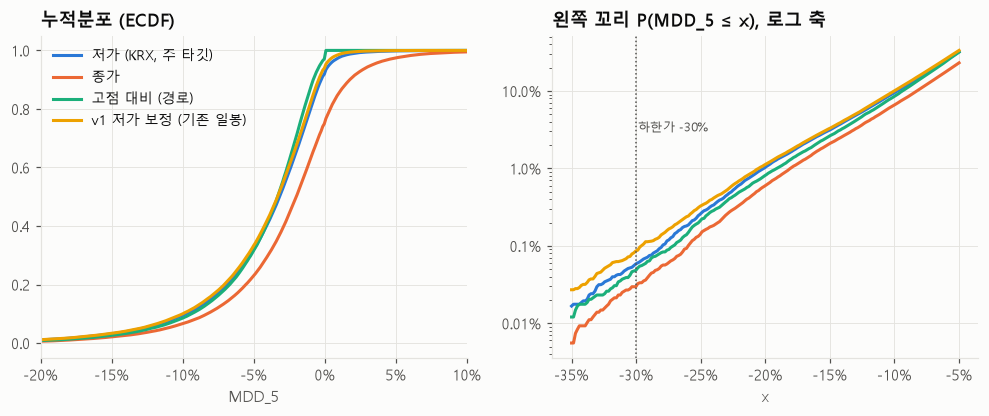

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
grid = np.linspace(-0.35, 0.1, 400)
for k in DEFS:
    x = np.sort(d[k].dropna().values)
    axes[0].plot(grid, np.searchsorted(x, grid, side="right") / len(x), color=COLOR[k], lw=2, label=LABEL[k])
axes[0].set_xlim(-0.2, 0.1)
axes[0].set_title("누적분포 (ECDF)")
axes[0].set_xlabel("MDD_5")
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
axes[0].legend(frameon=False, fontsize=9, loc="upper left")
# 왼쪽 꼬리: 로그 축
tail = np.linspace(-0.35, -0.05, 200)
for k in DEFS:
    x = np.sort(d[k].dropna().values)
    axes[1].plot(tail, np.searchsorted(x, tail, side="right") / len(x), color=COLOR[k], lw=2)
axes[1].set_yscale("log")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.1%}" if v >= 0.001 else f"{v:.2%}"))
axes[1].set_title("왼쪽 꼬리 P(MDD_5 ≤ x), 로그 축")
axes[1].set_xlabel("x")
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
axes[1].axvline(-0.30, color=P.TEXT_2, lw=1, ls=":")
axes[1].text(-0.298, 3e-2, "하한가 -30%", color=P.TEXT_2, fontsize=8, ha="left")
P.save(fig, "04_target_ecdf")
plt.show()

## 2. 정의 간 상관

In [5]:
pear = d[DEFS].corr().rename(index=LABEL, columns=LABEL)
spear = d[DEFS].corr(method="spearman").rename(index=LABEL, columns=LABEL)
print("Pearson (풀링)"); display(pear.round(3))
print("Spearman (풀링)"); display(spear.round(3))
# 날짜별 횡단면 Spearman의 평균
cs = {}
for a in DEFS:
    for b in DEFS:
        if a < b:
            r = d.groupby("trade_date").apply(lambda g: g[a].corr(g[b], method="spearman"))
            cs[f"{LABEL[a]} ~ {LABEL[b]}"] = r.mean()
pd.Series(cs).round(3).to_frame("날짜별 횡단면 Spearman 평균")

Pearson (풀링)


,"저가 (KRX, 주 타깃)",종가,고점 대비 (경로),v1 저가 보정 (기존 일봉)
"저가 (KRX, 주 타깃)",1.000,0.939,0.854,0.976
종가,0.939,1.000,0.804,0.912
고점 대비 (경로),0.854,0.804,1.000,0.853
v1 저가 보정 (기존 일봉),0.976,0.912,0.853,1.000


Spearman (풀링)


,"저가 (KRX, 주 타깃)",종가,고점 대비 (경로),v1 저가 보정 (기존 일봉)
"저가 (KRX, 주 타깃)",1.000,0.941,0.756,0.974
종가,0.941,1.000,0.760,0.916
고점 대비 (경로),0.756,0.760,1.000,0.755
v1 저가 보정 (기존 일봉),0.974,0.916,0.755,1.000


,날짜별 횡단면 Spearman 평균
"저가 (KRX, 주 타깃) ~ 고점 대비 (경로)",0.694
"저가 (KRX, 주 타깃) ~ v1 저가 보정 (기존 일봉)",0.963
"종가 ~ 저가 (KRX, 주 타깃)",0.919
종가 ~ 고점 대비 (경로),0.708
종가 ~ v1 저가 보정 (기존 일봉),0.890
고점 대비 (경로) ~ v1 저가 보정 (기존 일봉),0.688


## 3. 시간에 따른 변화 (월별)

In [6]:
mon = d.assign(ym=d.trade_date.dt.to_period("M").dt.to_timestamp())
mt = mon.groupby("ym").agg(**{f"{k}_median": (k, "median") for k in DEFS},
                           **{f"{k}_p10": (k, lambda s: s.quantile(0.10)) for k in DEFS},
                           share_le10_clean=("mdd_low", lambda s: (s <= -0.10).mean()),
                           n=("mdd_low", "size"))
display(mt[["mdd_low_median", "mdd_low_p10", "mdd_close_median", "share_le10_clean", "n"]].round(4))

,mdd_low_median,mdd_low_p10,mdd_close_median,share_le10_clean,n
ym,,,,,
2024-04-01,-0.0292,-0.0820,-0.0185,0.0521,4200
2024-05-01,-0.0285,-0.0743,-0.0203,0.0390,4000
2024-06-01,-0.0271,-0.0737,-0.0182,0.0378,3782
2024-07-01,-0.0338,-0.1262,-0.0235,0.1500,4580
2024-08-01,-0.0272,-0.1024,-0.0155,0.1033,4193
2024-09-01,-0.0327,-0.0852,-0.0206,0.0619,3584
2024-10-01,-0.0305,-0.0809,-0.0196,0.0501,4014
2024-11-01,-0.0392,-0.1201,-0.0280,0.1557,4214
2024-12-01,-0.0398,-0.0939,-0.0287,0.0836,4005


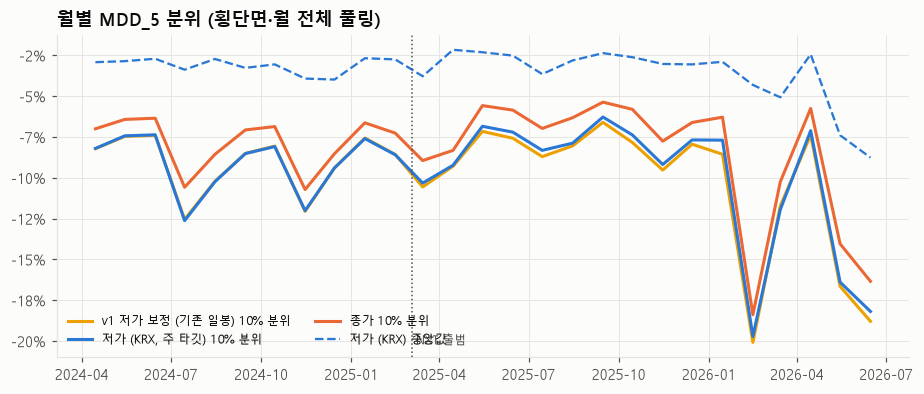

In [7]:
fig, ax = plt.subplots(figsize=(10, 3.8))
x = mt.index + pd.Timedelta(days=14)
for k, ls in [("v1_low_clean", "-"), ("mdd_low", "-"), ("mdd_close", "-")]:
    ax.plot(x, mt[f"{k}_p10"], color=COLOR[k], lw=2, label=f"{LABEL[k]} 10% 분위")
ax.plot(x, mt["mdd_low_median"], color=COLOR["mdd_low"], lw=1.5, ls="--", label="저가 (KRX) 중앙값")
ax.axvline(pd.Timestamp("2025-03-04"), color=P.TEXT_2, lw=1, ls=":")
ax.text(pd.Timestamp("2025-03-04"), ax.get_ylim()[0] * 0.97, " NXT 출범", color=P.TEXT_2, fontsize=8, va="bottom")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_title("월별 MDD_5 분위 (횡단면·월 전체 풀링)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.legend(frameon=False, fontsize=8, ncol=2, loc="lower left")
P.save(fig, "04_target_monthly")
plt.show()

In [8]:
# 분산 분해: 날짜 공통 요인(시장)이 설명하는 비중
for k in ["mdd_low", "mdd_close"]:
    dm = d.groupby("trade_date")[k].transform("mean")
    r2 = 1 - ((d[k] - dm) ** 2).sum() / ((d[k] - d[k].mean()) ** 2).sum()
    print(f"{LABEL[k]}: 날짜 평균이 설명하는 분산 비중 R² = {r2:.3f}")

저가 (KRX, 주 타깃): 날짜 평균이 설명하는 분산 비중 R² = 0.399
종가: 날짜 평균이 설명하는 분산 비중 R² = 0.348


## 4. 업종별 차이

In [9]:
# 업종은 stocks 테이블의 현재값(정적 속성으로 취급)
ind_path = ROOT / "data" / "cache" / "stocks_industry.parquet"
if not ind_path.exists():
    from src.db import read_sql
    read_sql("SELECT symbol, name, industry FROM stocks").to_parquet(ind_path, index=False)
names = pd.read_parquet(ind_path)
ind = d.merge(names[["symbol", "industry"]], on="symbol", how="left")
ind["industry"] = ind["industry"].fillna("(없음)")
# 날짜 효과를 뺀 횡단면 초과 MDD (같은 날 평균 대비)
ind["excess"] = ind["mdd_low"] - ind.groupby("trade_date")["mdd_low"].transform("mean")
gi = ind.groupby("industry").agg(n_stocks=("symbol", "nunique"), n=("excess", "size"),
                                 median_mdd=("mdd_low", "median"),
                                 share_le10=("mdd_low", lambda s: (s <= -0.10).mean()),
                                 mean_excess=("excess", "mean"))
gi = gi[gi.n_stocks >= 4].sort_values("mean_excess")
display(gi.round(4))
# 겹치지 않는 표본에서 Kruskal-Wallis (4종목 이상 업종, 날짜 효과 제거 후)
indn = ind[ind.trade_date.isin(sample_days) & ind.industry.isin(gi.index)]
h, p = stats.kruskal(*[g.excess.values for _, g in indn.groupby("industry")])
print(f"Kruskal-Wallis (겹치지 않는 표본, 업종 {indn.industry.nunique()}개): H={h:.1f}, p={p:.2e}")

,n_stocks,n,median_mdd,share_le10,mean_excess
industry,,,,,
1차 비철금속 제조업,4,1803,-0.0436,0.1963,-0.0152
일차전지 및 이차전지 제조업,8,3959,-0.0449,0.1740,-0.0133
"전동기, 발전기 및 전기 변환 · 공급 · 제어 장치 제조업",5,1845,-0.0440,0.1751,-0.0118
기초 화학물질 제조업,13,6039,-0.0413,0.1404,-0.0098
"건축기술, 엔지니어링 및 관련 기술 서비스업",4,1859,-0.0408,0.1372,-0.0082
1차 철강 제조업,5,2228,-0.0365,0.1338,-0.0069
전자부품 제조업,7,2875,-0.0373,0.1485,-0.0066
일반 목적용 기계 제조업,5,1850,-0.0371,0.1405,-0.0054
화학섬유 제조업,4,1919,-0.0356,0.1120,-0.0043


Kruskal-Wallis (겹치지 않는 표본, 업종 18개): H=398.9, p=3.12e-74


## 5. 시장 급락일 전후

급락일: KOSPI 종가 기준 일간 수익률 ≤ -3%인 날(분석 표본 기간). 급락일 d 기준 k일 떨어진 날(t = d + k)의 횡단면 평균 MDD_5를 본다. k = -5 ~ -1이면 타깃 구간에 급락일이 들어간다.

In [10]:
idx = load_table("market_indicator_daily_candles", S, E)
kospi = idx[idx.symbol == "KOSPI"].sort_values("trade_date").set_index("trade_date")
kret = kospi.close_price.pct_change()
crash = kret[(kret <= -0.03) & (kret.index >= "2024-04-01")]
print(f"급락일 {len(crash)}일:", ", ".join(f"{i.date()} ({v:.1%})" for i, v in crash.items()))
daily = d.groupby("trade_date")[DEFS].mean()
pos = {dt: i for i, dt in enumerate(cal)}
ev = []
for dt in crash.index:
    for k in range(-10, 11):
        j = pos[dt] + k
        if 0 <= j < len(cal) and cal[j] in daily.index:
            ev.append({"k": k, **daily.loc[cal[j]].to_dict()})
ev = pd.DataFrame(ev).groupby("k").mean()
base = daily.mean()
display(ev.round(4).T.assign(전체평균=base.round(4)).T.tail(22))

급락일 26일: 2024-08-02 (-3.7%), 2024-08-05 (-8.8%), 2024-09-04 (-3.1%), 2025-02-28 (-3.4%), 2025-03-31 (-3.0%), 2025-04-07 (-5.6%), 2025-08-01 (-3.9%), 2025-11-14 (-3.8%), 2025-11-18 (-3.3%), 2025-11-21 (-3.8%), 2026-02-02 (-5.3%), 2026-02-05 (-3.9%), 2026-03-03 (-7.2%), 2026-03-04 (-12.1%), 2026-03-09 (-6.0%), 2026-03-23 (-6.5%), 2026-03-26 (-3.2%), 2026-03-31 (-4.3%), 2026-04-02 (-4.5%), 2026-05-15 (-6.1%), 2026-05-19 (-3.3%), 2026-06-05 (-5.5%), 2026-06-08 (-8.3%), 2026-06-10 (-4.5%), 2026-06-23 (-10.0%), 2026-06-26 (-5.8%)


,mdd_low,mdd_close,mdd_path,v1_low_clean
k,,,,
-10,-0.0454,-0.0258,-0.0508,-0.0492
-9,-0.0513,-0.0330,-0.0532,-0.0550
-8,-0.0571,-0.0395,-0.0632,-0.0599
-7,-0.0644,-0.0459,-0.0663,-0.0684
-6,-0.0667,-0.0489,-0.0669,-0.0708
-5,-0.0811,-0.0646,-0.0878,-0.0852
-4,-0.0969,-0.0785,-0.0949,-0.0983
-3,-0.0854,-0.0656,-0.0871,-0.0895
-2,-0.0883,-0.0672,-0.0840,-0.0900


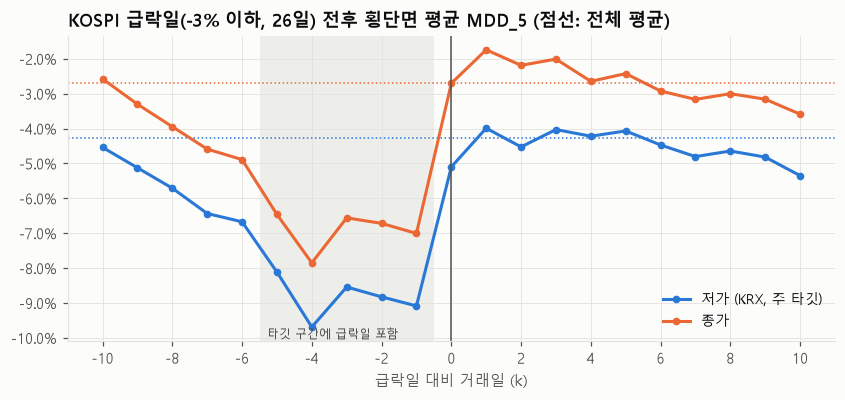

In [11]:
fig, ax = plt.subplots(figsize=(9, 3.6))
for k in ["mdd_low", "mdd_close"]:
    ax.plot(ev.index, ev[k], color=COLOR[k], lw=2, marker="o", ms=4, label=LABEL[k])
    ax.axhline(base[k], color=COLOR[k], lw=1, ls=":")
ax.axvspan(-5.5, -0.5, color=P.GRID, alpha=0.6, lw=0)
ax.text(-5.4, ax.get_ylim()[0], " 타깃 구간에 급락일 포함", color=P.TEXT_2, fontsize=8, va="bottom")
ax.axvline(0, color=P.TEXT_2, lw=1)
ax.set_xlabel("급락일 대비 거래일 (k)")
ax.set_xticks(range(-10, 11, 2))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.1%}"))
ax.set_title(f"KOSPI 급락일(-3% 이하, {len(crash)}일) 전후 횡단면 평균 MDD_5 (점선: 전체 평균)")
ax.legend(frameon=False, fontsize=9, loc="lower right")
P.save(fig, "04_target_crash_event")
plt.show()

## 6. 타깃의 자기상관 (t일에 알 수 있는 과거 실현값과 비교)

t일 기준으로 알 수 있는 값만 쓴다(t일 종가까지).
- `past_mdd5`: min(Low[t-4..t]) / Close[t-5] - 1. 이는 5거래일 전 표본의 타깃 mdd_low(t-5)과 같다(겹치지 않는 가장 최근 타깃).
- `past_mdd20`: 과거 20거래일 종가 경로의 고점 대비 최대 낙폭
- `past_vol20`: 과거 20거래일 일간 수익률 표준편차 (참고용)

In [12]:
cc = c.sort_values(["symbol", "trade_date"]).reset_index(drop=True)
cc["low_c"] = cc["low_price"]   # v2: KRX 정규장 저가(보정 불필요)
g = cc.groupby("symbol")
cc["past_mdd5"] = g.low_c.transform(lambda s: s.rolling(5).min()) / g.close_price.shift(5) - 1
def roll_mdd(s, n=20):
    a = s.to_numpy()
    out = np.full(len(a), np.nan)
    for i in range(n - 1, len(a)):
        w = a[i - n + 1: i + 1]
        out[i] = np.min(w / np.maximum.accumulate(w) - 1)
    return pd.Series(out, index=s.index)
cc["past_mdd20"] = g.close_price.transform(roll_mdd)
cc["past_vol20"] = g.close_price.transform(lambda s: s.pct_change().rolling(20).std())
x = d.merge(cc[["symbol", "trade_date", "past_mdd5", "past_mdd20", "past_vol20"]], on=["symbol", "trade_date"], how="left")
# 검증: past_mdd5(t) == mdd_low(t-5)
chk = cc[["symbol", "trade_date"]].assign(v=cc.past_mdd5).merge(
    tg.assign(trade_date=tg.groupby("symbol").trade_date.shift(-5))[["symbol", "trade_date", "mdd_low"]],
    on=["symbol", "trade_date"]).dropna()
print("past_mdd5(t)와 mdd_low(t-5) 최대 차이:", float((chk.v - chk.mdd_low).abs().max()))

def ic_table(frame, target, feats):
    rows = []
    for f in feats:
        ic = frame.groupby("trade_date").apply(lambda g_: g_[f].corr(g_[target], method="spearman")).dropna()
        icn = ic[ic.index.isin(sample_days)]
        rows.append({"변수": f, "평균 IC": ic.mean(), "IC 표준편차": ic.std(), "IC IR": ic.mean() / ic.std(),
                     "IC>0 비율": (ic > 0).mean(), "평균 IC (겹치지 않는 표본)": icn.mean(),
                     "t값 (겹치지 않는 표본)": icn.mean() / icn.std() * np.sqrt(len(icn)),
                     "풀링 Spearman": frame[[f, target]].corr(method="spearman").iloc[0, 1]})
    return pd.DataFrame(rows).set_index("변수")
feats = ["past_mdd5", "past_mdd20", "past_vol20"]
for tgt in ["mdd_low", "mdd_close"]:
    print(f"타깃: {LABEL[tgt]}"); display(ic_table(x, tgt, feats).round(3))

past_mdd5(t)와 mdd_low(t-5) 최대 차이: 0.0
타깃: 저가 (KRX, 주 타깃)


,평균 IC,IC 표준편차,IC IR,IC>0 비율,평균 IC (겹치지 않는 표본),t값 (겹치지 않는 표본),풀링 Spearman
변수,,,,,,,
past_mdd5,0.099,0.159,0.624,0.735,0.101,6.503,0.116
past_mdd20,0.154,0.185,0.836,0.807,0.148,8.923,0.119
past_vol20,-0.306,0.179,-1.716,0.044,-0.300,-17.387,-0.259


타깃: 종가


,평균 IC,IC 표준편차,IC IR,IC>0 비율,평균 IC (겹치지 않는 표본),t값 (겹치지 않는 표본),풀링 Spearman
변수,,,,,,,
past_mdd5,0.067,0.157,0.429,0.685,0.071,4.739,0.072
past_mdd20,0.108,0.186,0.578,0.722,0.098,5.768,0.073
past_vol20,-0.197,0.188,-1.047,0.137,-0.190,-10.611,-0.163


In [13]:
# 시장 전체 시계열: 날짜별 횡단면 평균 MDD_5의 자기상관
acf = {f"lag {L}": daily["mdd_low"].autocorr(L) for L in [1, 5, 10, 20]}
acf_past = daily["mdd_low"].corr(daily["mdd_low"].shift(5))
print("날짜별 평균 mdd_low 자기상관:", {k: round(v, 3) for k, v in acf.items()})
print("lag 1~4는 타깃 구간이 겹쳐 기계적으로 높다. t일에 알 수 있는 것은 lag 5 이상이다.")

날짜별 평균 mdd_low 자기상관: {'lag 1': np.float64(0.783), 'lag 5': np.float64(0.131), 'lag 10': np.float64(0.07), 'lag 20': np.float64(0.079)}
lag 1~4는 타깃 구간이 겹쳐 기계적으로 높다. t일에 알 수 있는 것은 lag 5 이상이다.


## 7. 분류 문제로 바꿀 때의 임계값 후보

In [14]:
thr = [-0.03, -0.05, -0.07, -0.10, -0.15]
cls = pd.DataFrame({LABEL[k]: [(d[k] <= t_).mean() for t_ in thr] for k in DEFS}, index=[f"≤ {t_:.0%}" for t_ in thr])
print("양성(위험) 클래스 비율"); display((cls * 100).round(2))
# 기간별 안정성: 반기별 양성 비율(보정 저가 기준)
hy = d.assign(half=d.trade_date.dt.year.astype(str) + "H" + ((d.trade_date.dt.month > 6) + 1).astype(str))
hyt = pd.DataFrame({f"≤ {t_:.0%}": hy.groupby("half").mdd_low.apply(lambda s: (s <= t_).mean()) for t_ in thr})
print("반기별 양성 비율 % (저가, KRX)"); display((hyt * 100).round(2))
# 날짜별 양성 비율의 분포: 하루 동안 양성이 0개인 날의 비율
for t_ in [-0.05, -0.10]:
    dp = d.groupby("trade_date").mdd_low.apply(lambda s: (s <= t_).mean())
    print(f"≤ {t_:.0%}: 날짜별 양성 비율 중앙값 {dp.median():.1%}, 최대 {dp.max():.1%}, 양성 0개인 날 {(dp == 0).mean():.1%}")

양성(위험) 클래스 비율


,"저가 (KRX, 주 타깃)",종가,고점 대비 (경로),v1 저가 보정 (기존 일봉)
≤ -3%,52.33,38.88,54.74,53.65
≤ -5%,32.06,23.09,31.71,33.13
≤ -7%,19.44,13.78,18.49,20.22
≤ -10%,9.46,6.59,8.52,9.91
≤ -15%,3.14,2.10,2.64,3.28


반기별 양성 비율 % (저가, KRX)


,≤ -3%,≤ -5%,≤ -7%,≤ -10%,≤ -15%
half,,,,,
2024H1,47.34,25.06,12.74,4.32,0.51
2024H2,54.43,33.98,20.74,10.31,3.44
2025H1,45.81,26.27,14.96,6.37,1.29
2025H2,48.70,26.21,13.50,4.79,0.93
2026H1,63.27,45.90,32.52,19.45,8.47


≤ -5%: 날짜별 양성 비율 중앙값 25.5%, 최대 100.0%, 양성 0개인 날 0.2%
≤ -10%: 날짜별 양성 비율 중앙값 4.0%, 최대 95.0%, 양성 0개인 날 3.5%


## 8. 타깃 캐시 저장

In [15]:
out = df[["trade_date", "symbol", "embargo", "rebal_gap_day", "halted", "halt_in_window", "halt_excluded", "use"] + DEFS + ["n_fwd"]]
out.to_parquet(ROOT / "data" / "cache" / "target_train.parquet", index=False)
print(out.shape, "저장: data/cache/target_train.parquet")

(109061, 13) 저장: data/cache/target_train.parquet


## 9. 결론과 타깃 정의 의견 (v2, KRX 정규장 일봉)

**표본**: 분석 표본 109,061쌍 중 타깃이 있는 108,061쌍에서 거래정지 관련 181쌍을 빼고 **107,880쌍**을 쓴다.

**분포 (주 타깃 `mdd_low`)**
- 평균 -4.3%, 중앙값 -3.2%, 10% 분위 -9.8%, 1% 분위 -20.1%다. 왜도 -1.7, 초과 첨도 4.9로 왼쪽 꼬리가 두껍다.
- 양수(5일 내내 기준가 위에 머문 경우)는 6.7%다. 원래 값 그대로 쓰기로 했다.
- ≤ -5%는 32.1%, ≤ -10%는 9.5%, ≤ -15%는 3.1%, ≤ -20%는 1.0%다.

**v1(기존 일봉, 보정 저가)과 비교**
- 같은 쌍에서 Spearman 0.974다.
- NXT 이전에는 |차이| > 1%p인 쌍이 0.01%로 사실상 같다. NXT 이후에는 15.8%가 1%p 넘게 다르다.
- NXT 이후 차이의 중앙값은 +0.1%p다. 정규장만 쓰면 장전·장후 거래가 빠져서 저가가 덜 낮게 잡힌다.
- 꼬리가 조금 얇아졌다. ≤ -20% 비율은 1.12%에서 1.03%로, 1% 분위는 -20.5%에서 -20.1%로 바뀌었다.

**시장 요인과 국면**
- 날짜 평균이 분산의 40%를 설명한다(v1은 39%).
- ≤ -10% 비율은 반기별로 2024H1 4.3%, 2024H2 10.3%, 2025H1 6.4%, 2025H2 4.8%, **2026H1 19.5%**다.
- 2026H1의 급락은 실제 사건이다(미국·이란 전쟁 충격). 예를 들어 2026-03-04 KOSPI -12.06%는 역대 최대 하락이다.
- 급락일을 타깃 구간에 포함한 표본(k = -5 ~ -1)의 평균 MDD_5는 약 -9%로, 전체 평균 -4.3%의 두 배다. 급락 다음 날부터는 평균에 가깝게 돌아온다.

**업종**: 차이가 유의하다(겹치지 않는 표본 Kruskal-Wallis p ≈ 3e-74). 같은 날 평균 대비 초과 낙폭은 비철금속 -1.5%p, 이차전지 -1.3%p, 전기장비 -1.2%p이고, 식품 +1.0%p, 소매 +0.9%p다.

**자기상관**: 과거 20일 변동성의 IC는 -0.306(IR -1.72), 과거 20일 MDD는 0.154, 과거 5일 MDD는 0.099다. 겹치지 않는 표본에서도 모두 |t| > 6이다.

**정의 의견**: 주 타깃은 **`mdd_low`(KRX 정규장 저가, 계획서 기본 정의)**다. 보정이 필요 없어졌고, 종가 기준보다 과거 변수와의 관계가 30 ~ 40% 강하다. 종가 기준과 경로 기준은 보조 확인용으로만 쓴다.